# Fraud Detection

## Objective

The objective of this project is to develop a machine learning–based fraud detection system that can identify fraudulent credit card transactions. By analyzing transaction patterns and applying classification algorithms, the model aims to distinguish between legitimate and fraudulent activities. This project demonstrates the practical application of anomaly detection and predictive modeling in financial security systems.

## Dataset Description

The dataset used in this project is a credit card transactions dataset. It contains anonymized transaction data collected from European cardholders. Each transaction is labeled as either legitimate or fraudulent.

The dataset includes numerical features obtained through Principal Component Analysis (PCA) to protect sensitive information. The target variable indicates whether a transaction is fraudulent (1) or legitimate (0). Due to the real-world nature of fraud detection, the dataset is highly imbalanced, with fraudulent transactions forming only a small fraction of the total data.

## Data Loading and Initial Exploration

In this section, the credit card transactions dataset is loaded and explored to understand its structure, dimensions, and feature composition. Initial exploration helps identify the number of records, feature types, and the presence of missing values before further preprocessing.

In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv("creditcard.csv")

# Display dataset shape
df.shape

(284807, 31)

In [2]:
# Display first few rows
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [4]:
# Check for missing values
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

## Data Analysis and Class Imbalance Check

Fraud detection datasets are typically highly imbalanced, with fraudulent transactions occurring far less frequently than legitimate ones. This section analyzes the distribution of transaction classes to understand the imbalance present in the dataset.

In [5]:
# Count values of each class
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [6]:
# Percentage distribution of classes
df['Class'].value_counts(normalize=True) * 100

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

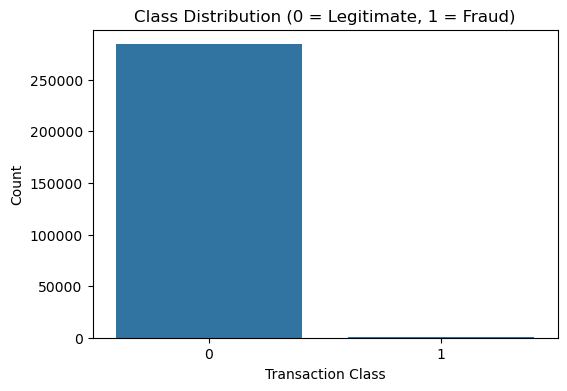

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title("Class Distribution (0 = Legitimate, 1 = Fraud)")
plt.xlabel("Transaction Class")
plt.ylabel("Count")
plt.show()

## Data Preprocessing and Feature Scaling

In this step, the dataset is prepared for model training by separating features and target labels, splitting the data into training and testing sets, and applying feature scaling to normalize the feature values.

In [8]:
# Separate features and target variable
X = df.drop('Class', axis=1)
y = df['Class']

### Train–Test Split

The dataset is split into training and testing sets to evaluate model performance on unseen data.

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### Feature Scaling

Feature scaling is applied to normalize numerical values so that all features contribute equally to model training.

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Data preprocessing and feature scaling are completed.  
The dataset is now ready for machine learning model training.

## Model Training – Logistic Regression

Logistic Regression is used as a baseline classification model to detect fraudulent transactions based on the processed and scaled features.

In [11]:
from sklearn.linear_model import LogisticRegression

# Initialize Logistic Regression model
log_reg = LogisticRegression(max_iter=1000, random_state=42)

# Train the model
log_reg.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


## Model Evaluation – Logistic Regression

The trained Logistic Regression model is evaluated using standard classification metrics to assess its ability to detect fraudulent transactions.

In [12]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Predict on test data
y_pred_lr = log_reg.predict(X_test_scaled)

# Accuracy
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print("Accuracy:", accuracy_lr)

# Classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr, zero_division=0))

# Confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
print("\nConfusion Matrix:\n")
print(cm_lr)

Accuracy: 0.9991397773954567

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.63      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962


Confusion Matrix:

[[56851    13]
 [   36    62]]


The evaluation results provide insights into the model’s performance, particularly its ability to correctly identify fraudulent transactions in an imbalanced dataset.

## Model Training – Decision Tree

A Decision Tree classifier is trained to detect fraudulent transactions by learning decision rules derived from the input features.

In [13]:
from sklearn.tree import DecisionTreeClassifier

# Initialize Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model
dt_model.fit(X_train_scaled, y_train)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


## Model Evaluation – Decision Tree

The Decision Tree model is evaluated to measure its effectiveness in identifying fraudulent and non-fraudulent transactions.

In [14]:
# Predict on test data
y_pred_dt = dt_model.predict(X_test_scaled)

# Accuracy
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print("Accuracy:", accuracy_dt)

# Classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_dt, zero_division=0))

# Confusion matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
print("\nConfusion Matrix:\n")
print(cm_dt)

Accuracy: 0.9991397773954567

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.75      0.74      0.75        98

    accuracy                           1.00     56962
   macro avg       0.88      0.87      0.87     56962
weighted avg       1.00      1.00      1.00     56962


Confusion Matrix:

[[56840    24]
 [   25    73]]


The Decision Tree evaluation results highlight how well the model captures patterns related to fraudulent behavior.

## Neural Network Model (Multi-Layer Perceptron)

A Neural Network model is implemented using a Multi-Layer Perceptron (MLP) classifier.  
This model is capable of learning complex non-linear patterns in the data, which is useful for detecting fraudulent transactions in highly imbalanced datasets.

The model is trained on the scaled training data and evaluated using accuracy, classification report, and confusion matrix.

In [15]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize Neural Network (MLP) model
mlp_model = MLPClassifier(hidden_layer_sizes=(100,),
                          max_iter=300,
                          random_state=42)

# Train the model
mlp_model.fit(X_train_scaled, y_train)

# Predict on test data
y_pred_mlp = mlp_model.predict(X_test_scaled)

# Accuracy
accuracy_mlp = accuracy_score(y_test, y_pred_mlp)
print("Accuracy:", accuracy_mlp)

# Classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_mlp, zero_division=0))

# Confusion matrix
cm_mlp = confusion_matrix(y_test, y_pred_mlp)
print("\nConfusion Matrix:\n")
print(cm_mlp)

Accuracy: 0.9994733330992591

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.82      0.84        98

    accuracy                           1.00     56962
   macro avg       0.93      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962


Confusion Matrix:

[[56852    12]
 [   18    80]]


## Model Performance Comparison

In this section, the performance of all trained models is compared to determine the most effective model for fraud detection.

The comparison is based on accuracy and classification performance, considering the highly imbalanced nature of the dataset.

In [16]:
import pandas as pd

# Create a comparison table
model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Neural Network (MLP)'],
    'Accuracy': [accuracy_lr, accuracy_dt, accuracy_mlp]
})

model_comparison

,Model,Accuracy
0,Logistic Regression,0.999140
1,Decision Tree,0.999140
2,Neural Network (MLP),0.999473


## Best Model Selection

Three machine learning models—Logistic Regression, Decision Tree, and Neural Network (MLP)—were trained and evaluated for fraud detection using the same dataset and evaluation metric.

Although Logistic Regression and Decision Tree achieved identical accuracy values, the Neural Network (MLP) model recorded the highest accuracy among all three models. This indicates that the Neural Network was slightly more effective in capturing complex patterns within the highly imbalanced fraud detection dataset.

Therefore, based on comparative performance, the Neural Network (MLP) model is selected as the best-performing model for this task.

## Conclusion

This project successfully demonstrated the application of machine learning techniques for fraud detection using financial transaction data. The workflow included data exploration, handling class imbalance, feature scaling, model training, and evaluation.

Three classification models—Logistic Regression, Decision Tree, and Neural Network (MLP)—were implemented and compared. Due to the highly imbalanced nature of the dataset, similar accuracy values were observed for some models. However, the Neural Network (MLP) achieved the highest accuracy and was selected as the best model.

Overall, this task provided practical experience in anomaly detection, predictive modeling, and performance evaluation, fulfilling the objectives of the fraud detection project.